In [2]:
import sys
sys.path.append("../../src/")
import TFIM_operators_from_states as op

from project_imports import *

In [125]:
def e(k,h):
    return 2*sqrt(1+h*h-2*h*cos(k))
def theta(k,h):
    return np.arctan2(-sin(k),h-cos(k))
def delta(k,h,h0):
    return theta(k,h)-theta(k,h0)
def A(k,h,t,h0=-2):
    d = delta(k,h,h0)
    th = theta(k,h)
    x = e(k,h)
    ph = exp(-1j*x*t)
    return cos(th/2)*cos(d/2)*ph+sin(th/2)*sin(d/2)*np.conj(ph)
def B(k,h,t,h0=-2):
    d = delta(k,h,h0)
    th = theta(k,h)
    x = e(k,h)
    ph = exp(-1j*x*t)
    return -1j*cos(th/2)*sin(d/2)*ph+1j*sin(th/2)*cos(d/2)*np.conj(ph)


In [126]:
def aa(k,h,t):
    return A(k,h,t)*B(-k,h,t)
def ca(k,h,t):
    return np.abs(B(k,h,t))**2
def cc(k,h,t):
    return np.conj(aa(-k,h,t))
def ac(k,h,t):
    return 1-ca(k,h,t)


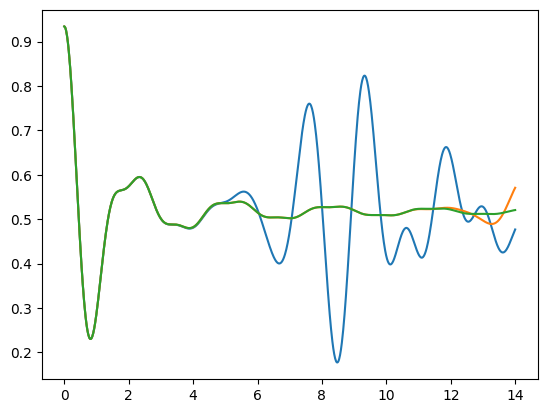

In [127]:
#Testing quench
hf= -1/2
Ls = [16,32,64]
for L in Ls:
    
    k = 2*pi/L *( np.arange(0,L)+1/2)
    t = np.linspace(0,14,1000)
    tryit = 2/L*array([np.sum([ca(ki,hf,ti) for ki in k]) for ti in t])-1
    plot(t,tryit)

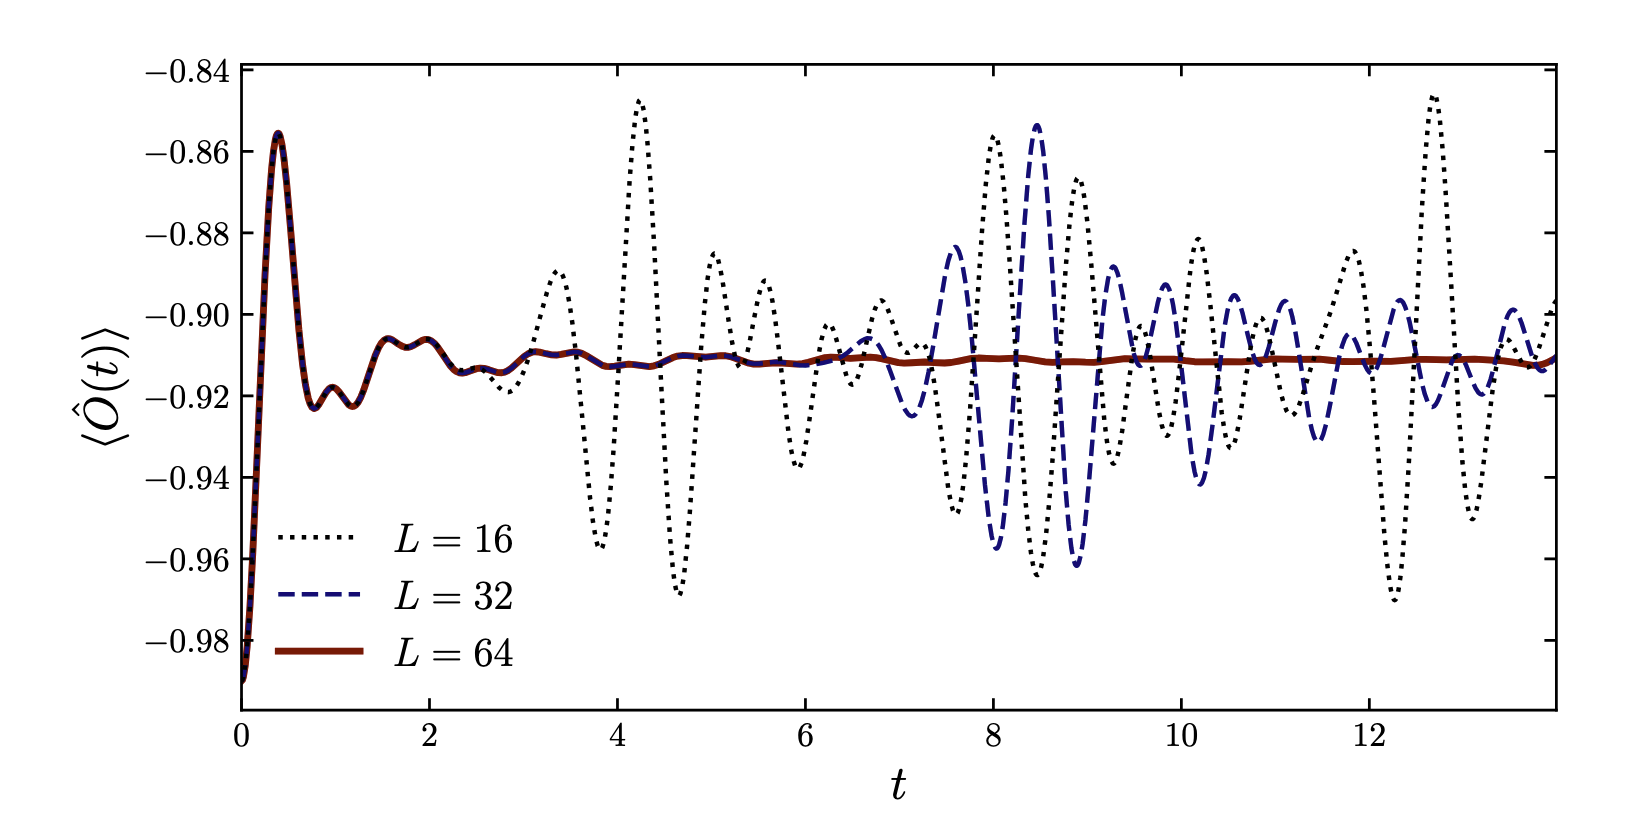

# So, this exactly works.
Let's go forward.

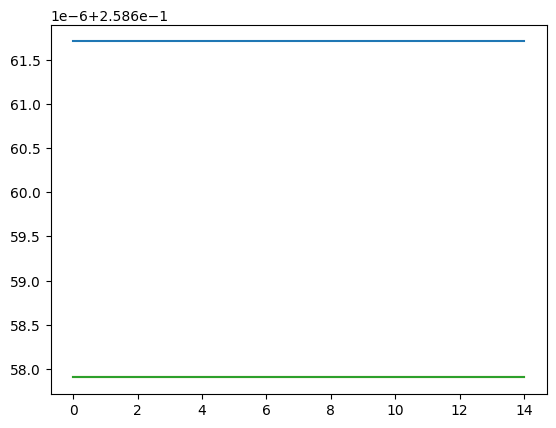

In [129]:
#Testing quench
hf= 0
Ls = [16,32,64]
t = np.linspace(0,14,1000)
r=0
for L in Ls:
    
    k = 2*pi/L *( np.arange(0,L)+1/2)
    dat=array([np.sum(2*cos(k)*ca(k,hf,ti)+1j*sin(k)*(aa(-k,hf,ti)-cc(k,hf,ti))) for ti in t]      )
    plot(t,dat/L)

#ylim(0,1)

In [ ]:
def BA(k,hf,ti,r):
    terms = exp(1j*k*r)*(1
                         -2*abs(B(k,hf,ti))**2
                        +2*np.real(exp(1j*k)*A(k,hf,ti)
                                    ))
    return np.average(terms)

def A(k,hf,ti,r):
    terms = exp(1j*k*r)*(1
                         -2*abs(B(k,hf,ti))**2
                        +2*np.real(exp(1j*k)*A(k,hf,ti)
                                    ))
    return np.average(terms)

In [156]:
def BA(k, h, t, r):
    terms = np.exp(1j*k*r)*(
        ca(k, h, t)
        + ca(-k,h,t)-1
        + cc(k,h,t)-aa(-k,h,t)
    )
    return np.mean(terms)   # (1/L) sum_k
def AA(k, h, t, r):
    terms = np.exp(1j*k*r)*(1+
        aa(-k,h,t)+cc(k,h,t)
    )
    return np.mean(terms)   # (1/L) sum_k
def BB(k, h, t, r):
    terms = np.exp(1j*k*r)*(-1+
        aa(-k,h,t)+cc(k,h,t)
    )
    return np.mean(terms)   # (1/L) sum_k


np.complex128(5.204170427930421e-17-1.1275702593849246e-17j)

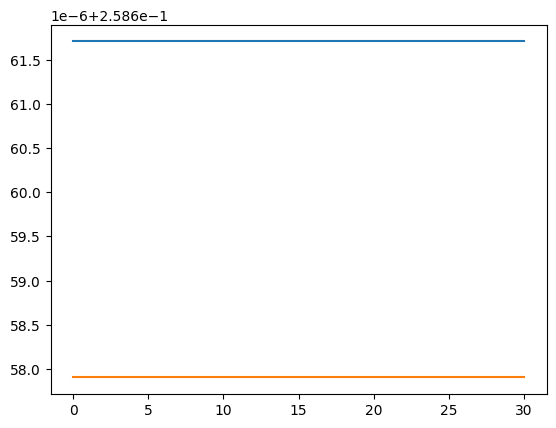

In [177]:
#Testing quench
hf= 0
Ls = [16,200]
t = np.linspace(0,30,1000)
r=-1
for L in Ls:
    
    k = 2*pi/L *( np.arange(0,L)+1/2)
    dat=array([(BA(k,hf,ti,r)) for ti in t])
    plot(t,dat)

#ylim(0,1)

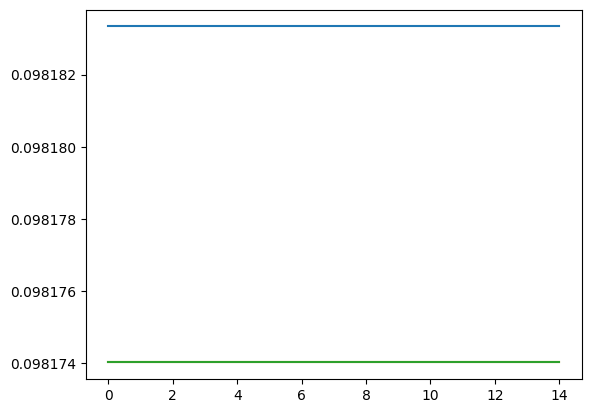

In [178]:
#Testing quench
hf= 0
Ls = [16,32,64]
t = np.linspace(0,14,1000)
for L in Ls:
    
    k = 2*pi/L *( np.arange(0,L)+1/2)
    dat=array([(BA(k,hf,ti,-1))**2-BA(k,hf,ti,-2)*BA(k,hf,ti,0)-BB(k,hf,ti,1)*AA(k,hf,ti,1)
               
               for ti in t])
    plot(t,dat)

#ylim(0,1)

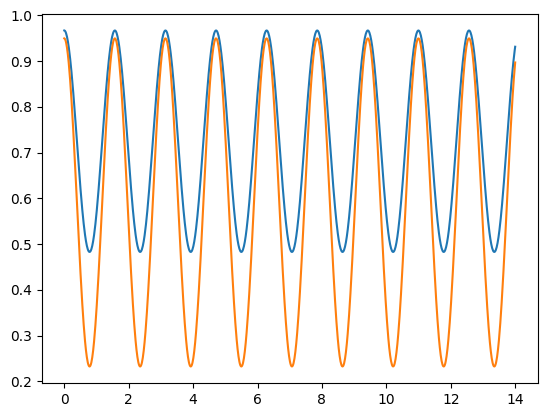

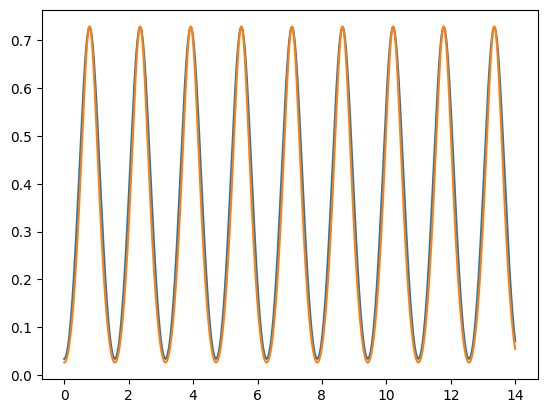

In [193]:
#Testing quench
hf= 0
Ls = [10]
t = np.linspace(0,14,1000)
for L in Ls:
    
    k = 2*pi/L *( np.arange(0,L)+1/2)
    z= array([BA(k,hf,ti,0) for ti in t])
    zz=array([(BA(k,hf,ti,0))**2
               -BB(k,hf,ti,-1)*AA(k,hf,ti,-1)*1
               -BA(k,hf,ti,-1)*BA(k,hf,ti,1)
               
               for ti in t])
    P1= (1+z)/2
    P2 = (1+2*z+zz)/4
    plot(t,P1)
    plot(t,P2)
    show()
    plot(t,-log(P1))
    plot(t,-log(P2)/2)

#ylim(0,1)

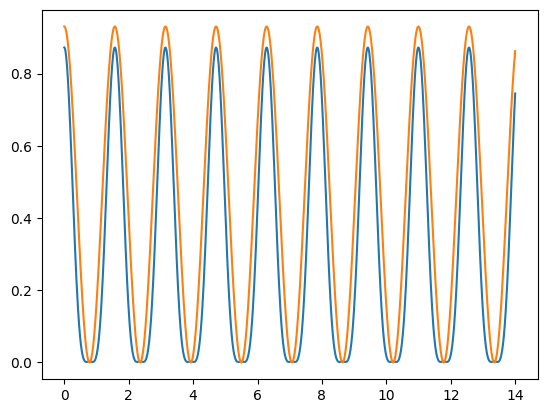

In [203]:
#Testing quench
hf= 0
Ls = [10]
t = np.linspace(0,14,1000)
for L in Ls:
    
    k = 2*pi/L *( np.arange(0,L)+1/2)
    z= array([BA(k,hf,ti,0) for ti in t])
    zz=array([(BA(k,hf,ti,0))**2
               -BB(k,hf,ti,-1)*AA(k,hf,ti,-1)*1
               -BA(k,hf,ti,-1)*BA(k,hf,ti,1)
               
               for ti in t])
    P1= (1+z)/2
    P2 = (1+2*z+zz)/4
    plot(t,z**2)
    plot(t,zz)

#ylim(0,1)

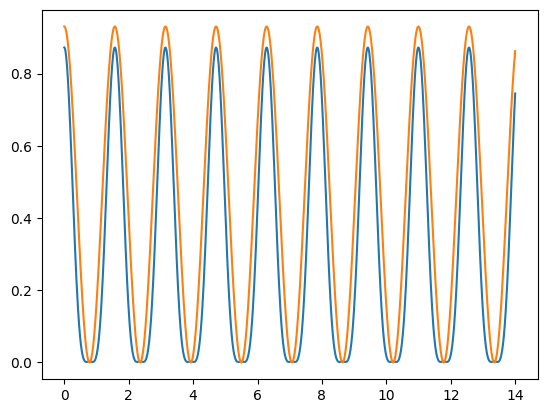

In [200]:
#Testing quench
hf= 0
Ls = [10]
t = np.linspace(0,14,1000)
for L in Ls:
    
    k = 2*pi/L *( np.arange(0,L)+1/2)
    z= array([BA(k,hf,ti,0) for ti in t])
    zz=array([(BA(k,hf,ti,0))**2
               -BB(k,hf,ti,-1)*AA(k,hf,ti,-1)*1
               -BA(k,hf,ti,-1)*BA(k,hf,ti,1)
               
               for ti in t])
    P1= (1+z)/2
    P2 = (1+2*z+zz)/4
    plot(t,z**2)
    plot(t,zz)

#ylim(0,1)